In [1]:
import subprocess


def _detect_gpu():
    try:
        import torch
        if torch.cuda.is_available():
            return True, torch.cuda.get_device_name(0)
    except ImportError:
        pass
    try:
        subprocess.run(["nvidia-smi"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        return True, "GPU (via nvidia-smi)"
    except (FileNotFoundError, subprocess.CalledProcessError):
        return False, None


USE_GPU, _gpu_name = _detect_gpu()

# XGBoost's unified device API (xgboost >= 2.0): merge into every XGBClassifier/XGBRegressor call
# so training runs on the GPU when one is available, and falls back to CPU otherwise.
XGB_GPU_PARAMS = {"tree_method": "hist", "device": "cuda"} if USE_GPU else {"tree_method": "hist", "device": "cpu"}

if USE_GPU:
    print(f"GPU detected ({_gpu_name}) -> training will run on CUDA.")
else:
    print("No GPU detected -> falling back to CPU.")

GPU detected (GPU (via nvidia-smi)) -> training will run on CUDA.


# Model Devoplopment

**Importing the dateset after the prepocessing..**

### **The Models:**

1. **Classification Model:** predicts whether the flight will be late more than 15 minuts or less.

   - Baseline Model: Logistic Regression
   - Other Models: XGBoost Classifier

2. **Regression Model:** predicts the delay time in minutes.
   - Baseline Model: Linear Regression
   - Other Models: Random Forest and XGBoost Regressor

# 1. Importing libraries and reading data

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

MainDF = pd.read_csv("Cleaned_Flights_2018.csv")
MainDF.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,ArrTime,AirTime,...,DistanceGroup,DivAirportLandings,Delay,Delayed,Dep_mins,CRSDep_mins,DepDelay,Arr_mins,CRSArr_mins,ArrDelay
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,0,0,1202,1157.0,1256.0,38.0,...,1,0.0,0.0,0,717.0,722,0.0,776.0,784,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,0,0,1202,1157.0,1258.0,36.0,...,1,0.0,0.0,0,717.0,722,0.0,778.0,784,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,0,0,1202,1153.0,1302.0,40.0,...,1,0.0,7.0,0,713.0,722,0.0,782.0,784,0.0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,0,0,1202,1150.0,1253.0,35.0,...,1,0.0,1.0,0,710.0,722,0.0,773.0,784,0.0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,0,0,1400,1355.0,1459.0,36.0,...,1,0.0,4.0,0,835.0,840,0.0,899.0,900,0.0


In [3]:
MainDF.shape

(5598897, 41)

In [4]:
MainDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 5598897 entries, 0 to 5598896
Data columns (total 41 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   FlightDate                               str    
 1   Airline                                  str    
 2   Origin                                   str    
 3   Dest                                     str    
 4   Cancelled                                int64  
 5   Diverted                                 int64  
 6   CRSDepTime                               int64  
 7   DepTime                                  float64
 8   ArrTime                                  float64
 9   AirTime                                  float64
 10  CRSElapsedTime                           float64
 11  ActualElapsedTime                        float64
 12  Distance                                 float64
 13  Quarter                                  int64  
 14  Month                        

In [5]:
MainDF["Delayed"].value_counts()

Delayed
0    5232700
1     366197
Name: count, dtype: int64

In [6]:
MainDF.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'ArrTime', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'Operating_Airline',
       'OriginAirportID', 'OriginCityName', 'OriginState', 'OriginStateName',
       'DestAirportID', 'DestCityName', 'DestState', 'DestStateName',
       'DepTimeBlk', 'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup',
       'DivAirportLandings', 'Delay', 'Delayed', 'Dep_mins', 'CRSDep_mins',
       'DepDelay', 'Arr_mins', 'CRSArr_mins', 'ArrDelay'],
      dtype='str')

# 2. Fix Imbalance using .sample() method
   - We took the length of Class 1 --> Delayed Flights
   - using .sample() we took a random sample of Class 0 --> On time flight or less than 15 min delay. which is in the size of calss 1, but subtracted 5000 samples from it.
   - Explain: To reduce class imbalance while maintaining higher sensitivity toward delayed flights.



In [7]:
# we wanna balance data
#1. Separate Minority and Majority Classes (DataFrames)
df_majority = MainDF[MainDF["Delayed"] == 0]
df_minority = MainDF[MainDF["Delayed"] == 1]

minority_size = len(df_minority) # OUR CHOICE
# 2. Undersample the Majority Class (sampling rows from the DataFrame)
df_majority_undersampled = df_majority.sample(n= (minority_size - 5000),
                replace=False, random_state=42)

# 3. Combine the Undersampled Majority with the Minority
delay_df_balanced = pd.concat([df_majority_undersampled, df_minority]) # the new df with all feature but balanced delayed

In [8]:
delay_df_balanced["Delayed"].value_counts()

Delayed
1    366197
0    361197
Name: count, dtype: int64

In [9]:
delay_df_balanced['DestStateName'].unique()


<StringArray>
[                                    'California',
                                        'Florida',
                                       'Colorado',
                                         'Nevada',
                                 'North Carolina',
                                       'Virginia',
                                       'Michigan',
                                       'New York',
                                        'Arizona',
                                       'Missouri',
                                      'Tennessee',
                                       'Nebraska',
                                       'Illinois',
                                     'New Jersey',
                                         'Hawaii',
                                          'Texas',
                                           'Utah',
                                       'Kentucky',
                                       'Maryland',
                 

In [10]:
delay_df_balanced.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'ArrTime', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'Operating_Airline',
       'OriginAirportID', 'OriginCityName', 'OriginState', 'OriginStateName',
       'DestAirportID', 'DestCityName', 'DestState', 'DestStateName',
       'DepTimeBlk', 'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup',
       'DivAirportLandings', 'Delay', 'Delayed', 'Dep_mins', 'CRSDep_mins',
       'DepDelay', 'Arr_mins', 'CRSArr_mins', 'ArrDelay'],
      dtype='str')

# 3. Feature Extraction and Setting Targets

In [11]:

#calssification model for is delayed AND REGRESSION TARGET
SELECTED_FEATURES = ['Airline','DepTime','CRSElapsedTime','Month','DayofMonth',
 'DayOfWeek','DestStateName','DistanceGroup','DepDelay', 'Delay', 'Delayed']

delay_df_balanced = delay_df_balanced[SELECTED_FEATURES]
delay_df_balanced = delay_df_balanced.dropna(subset=['Delay'])

# Create the feature matrix (X) and the target vector (y).
x_class = delay_df_balanced.drop(['Delay', 'Delayed'], axis=1)
y_class = delay_df_balanced['Delayed']


x_reg = delay_df_balanced.drop(['Delay', 'Delayed'], axis=1)
y_reg = delay_df_balanced['Delay']

# 4. Endcoding + Scaling + Transform:
  - splitting num from categorical
  - Preprocessing using a pipline

In [12]:
# splitting num from categorical
numeric_features = ['DepTime','CRSElapsedTime','Month','DayofMonth',
                    'DayOfWeek','DistanceGroup','DepDelay']

categorical_features = ['Airline','DestStateName']

# Preprocessing using a pipline
preprocess = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features),
                  ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)]
)

#5.  First Model: Classify whether if its more than 15 minutes delay or not

### 1. Baseline: Classification - Logistic Regression model

In [13]:
model = Pipeline(steps=[('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=10000))
])

# Train-test split
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_class, y_class, test_size=0.2, random_state=42)

# Split Train into Train-Validation
x_train_c, x_val_c, y_train_c, y_val_c = train_test_split(
    x_train_c, y_train_c, test_size=0.25, random_state=42, stratify=y_train_c)


# 7. Train
model.fit(x_train_c, y_train_c)


print("Train shape: ", x_train_c.shape)
print("Val shape: ", x_val_c.shape)
print("Test shape: ", x_test_c.shape)

Train shape:  (435936, 9)
Val shape:  (145312, 9)
Test shape:  (145313, 9)


In [14]:
# 8. Evaluate
print("Accuracy:", model.score(x_test_c, y_test_c))

Accuracy: 0.6072959748955703


### Logistic Regression Accuracy scores for our classification

In [15]:
y_pred_c_lr = model.predict(x_test_c)

# Print classification report
print(classification_report(y_test_c, y_pred_c_lr))

              precision    recall  f1-score   support

           0       0.62      0.53      0.57     72033
           1       0.60      0.69      0.64     73280

    accuracy                           0.61    145313
   macro avg       0.61      0.61      0.60    145313
weighted avg       0.61      0.61      0.60    145313



### Logistic Regression predction vs test for 10 samples

In [16]:
results_df = pd.DataFrame({
    "Actual Delay": y_test_c.values[:10],
    "Predicted Delay": y_pred_c_lr[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)


First 10 predictions:

   Actual Delay  Predicted Delay
0             0                1
1             1                1
2             1                1
3             0                0
4             0                0
5             0                1
6             1                1
7             1                0
8             0                1
9             1                1




---


### 2. Second classification models:XGBClassifier



In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', XGBClassifier(
        n_estimators = 500,
        learning_rate = 0.05,
        max_depth = 5,
        min_child_weight = 3,
        subsample = 0.8,
        colsample_bytree = 0.7,
        gamma = 0.1,
        reg_lambda = 1.0,       # L2
        reg_alpha = 0.1,        # L1
        eval_metric = "logloss",
        **XGB_GPU_PARAMS
    ))
])

xgb_model.fit(x_train_c, y_train_c)

y_pred_xgb = xgb_model.predict(x_test_c)

print("XGBoost Classification Report:")
print(classification_report(y_test_c, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.60      0.63     72033
           1       0.64      0.70      0.67     73280

    accuracy                           0.65    145313
   macro avg       0.65      0.65      0.65    145313
weighted avg       0.65      0.65      0.65    145313



c:\Users\Khalid\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\core.py:751: UserWarning: [04:22:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


### XGBoost Classifier predction vs test for 10 samples

In [18]:
results_df = pd.DataFrame({
    "Actual Delay": y_test_c.values[:10],
    "Predicted Delay": y_pred_xgb[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)


First 10 predictions:

   Actual Delay  Predicted Delay
0             0                0
1             1                0
2             1                1
3             0                0
4             0                0
5             0                1
6             1                1
7             1                0
8             0                1
9             1                1


# In conclusion: F1 Score in GXBoost Classifier gave us higher score.

# 6. Second Model: Regression Models to predict delay time in minuts

### 1. Baseline Model: Linear regression   

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# using a pipeline and preprocessing pipeline used before
reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])

In [20]:
# Train-Test Split
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42)

# Train-Validation Split
x_train_r, x_val_r, y_train_r, y_val_r = train_test_split(
    x_train_r, y_train_r, test_size=0.25, random_state=42)

print("Train shape: ", x_train_c.shape)
print("Val shape: ", x_val_c.shape)
print("Test shape: ", x_test_c.shape)

# 6. Train
reg_model.fit(x_train_r, y_train_r)

# 7. Predict
y_pred_r = reg_model.predict(x_test_r)

Train shape:  (435936, 9)
Val shape:  (145312, 9)
Test shape:  (145313, 9)


### Loss function results for baseline model (linear regression) and oredicted vs. actual 10 samples

In [21]:
# 8. Evaluate
mae_lr= mean_absolute_error(y_test_r, y_pred_r)
mse_lr = mean_squared_error(y_test_r, y_pred_r)
rmse_lr = mse_lr ** 0.5

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

# 5. Show first 10 predictions
results_df = pd.DataFrame({
    "Actual Delay": y_test_r.values[:10],
    "Predicted Delay": y_pred_r[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)

MAE: 12.708694219084727
RMSE: 17.285928450671012

First 10 predictions:

   Actual Delay  Predicted Delay
0           2.0        15.209531
1          15.0        13.403682
2          15.0        15.798901
3           2.0        11.565818
4           0.0        11.618755
5           0.0        17.486375
6          19.0        17.790129
7          22.0        11.080402
8          13.0        16.041358
9          27.0        17.600077


### 2. Second Model: Random Forest Regressor

In [22]:
from sklearn.ensemble import RandomForestRegressor


# parameters set to meet the defults or near the defults which suits our dataset and cae
reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1,
        max_features='sqrt'

    ))
])

### Loss function results for baseline model (random forest regressor) and oredicted vs. actual 10 samples

In [23]:
reg_model.fit(x_train_r, y_train_r)

# 3. Predict
y_pred_r_rf = reg_model.predict(x_test_r)

# 4. Evaluate
mae = mean_absolute_error(y_test_r, y_pred_r_rf)
rmse = mean_squared_error(y_test_r, y_pred_r_rf) ** 0.5

print("Random Forest Results:")
print("MAE:", mae)
print("RMSE:", rmse)

# 5. Show first 10 predictions
results_df = pd.DataFrame({
    "Actual Delay": y_test_r.values[:10],
    "Predicted Delay": y_pred_r_rf[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)

Random Forest Results:
MAE: 12.488557349163855
RMSE: 16.89901854173035

First 10 predictions:

   Actual Delay  Predicted Delay
0           2.0        13.214203
1          15.0        13.009241
2          15.0        16.467012
3           2.0        12.424618
4           0.0        12.310945
5           0.0        18.287270
6          19.0        16.368849
7          22.0        10.338759
8          13.0        17.529114
9          27.0        18.491234


### 3. Third Model: XGBoost Regressor

In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

xgb_reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', XGBRegressor(
        n_estimators = 500,
        learning_rate = 0.05,
        max_depth = 5,
        min_child_weight = 3,
        subsample = 0.8,
        colsample_bytree = 0.7,
        gamma = 0.1,
        reg_lambda = 1.0,       # L2
        reg_alpha = 0.1,        # L1
        eval_metric = "rmse", #for regression
        **XGB_GPU_PARAMS
    ))
])

xgb_reg_model.fit(x_train_r, y_train_r)

y_pred_xgb_r = xgb_reg_model.predict(x_test_r)

mae_xgb = mean_absolute_error(y_test_r, y_pred_xgb_r)
rmse_xgb = mean_squared_error(y_test_r, y_pred_xgb_r) ** 0.5

print("XGBoost Regressor Results:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

# Show first 10 predictions
results_df_xgb = pd.DataFrame({
    "Actual Delay": y_test_r.values[:10],
    "Predicted Delay": y_pred_xgb_r[:10]
})

print("\nFirst 10 predictions (XGBoost Regressor):\n")
print(results_df_xgb)

XGBoost Regressor Results:
MAE: 12.136274540995236
RMSE: 16.56564154453503

First 10 predictions (XGBoost Regressor):

   Actual Delay  Predicted Delay
0           2.0        10.779943
1          15.0        12.180782
2          15.0        16.848965
3           2.0         9.630228
4           0.0        14.759456
5           0.0        16.110832
6          19.0        17.659370
7          22.0         9.805483
8          13.0        19.128635
9          27.0        17.724024


# 7. Comparasion

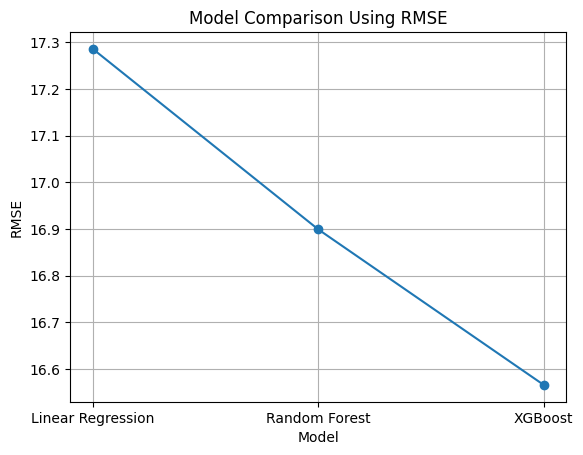

In [25]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_values = [rmse_lr, rmse, rmse_xgb]

plt.figure()
plt.plot(models, rmse_values, marker='o')
plt.title('Model Comparison Using RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


We see that XGBoost is best combination of performance + Accuracy